<a href="https://colab.research.google.com/github/Sreejabakthul/TASK/blob/main/Netflix_Data_Visualization_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          

In [14]:
df.shape

(8807, 12)

In [15]:
#Handling Missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Which Type of Content is More Available on Netflix?

In [16]:
content_count = df['type'].value_counts()
print(content_count)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


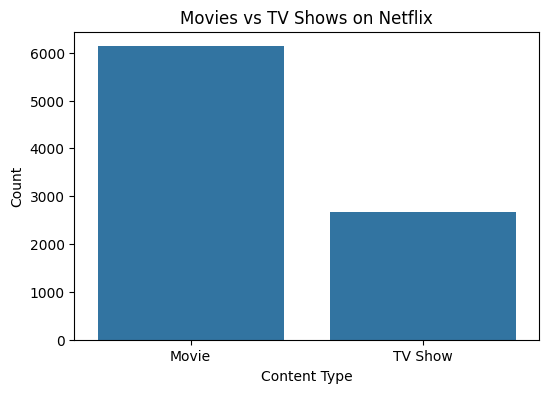

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

In [19]:
if content_count['Movie'] > content_count['TV Show']:
    print("Movies are more available on Netflix.")
else:
    print("TV Shows are more available on Netflix.")

Movies are more available on Netflix.


#Which Countries Contribute the Most Content?

In [20]:
countries = df['country'].dropna().str.split(', ')

In [21]:
country_list = []

for row in countries:
    country_list.extend(row)

country_df = pd.Series(country_list)
top_countries = country_df.value_counts().head(10)

print(top_countries)

United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


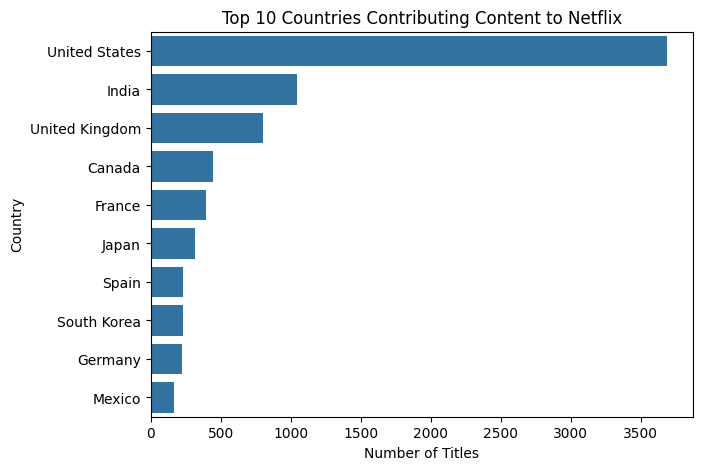

In [34]:
plt.figure(figsize=(7,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Contributing Content to Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [24]:
print("Top contributing country:", top_countries.index[0])

Top contributing country: United States


# Which Directors Have the Most Titles on Netflix?

In [25]:
directors = df['director'].dropna().str.split(', ')

In [35]:
director_list = []
for row in directors:
    director_list.extend(row)
director_df = pd.Series(director_list)
top_directors = director_df.value_counts().head(10)
print(top_directors)

Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


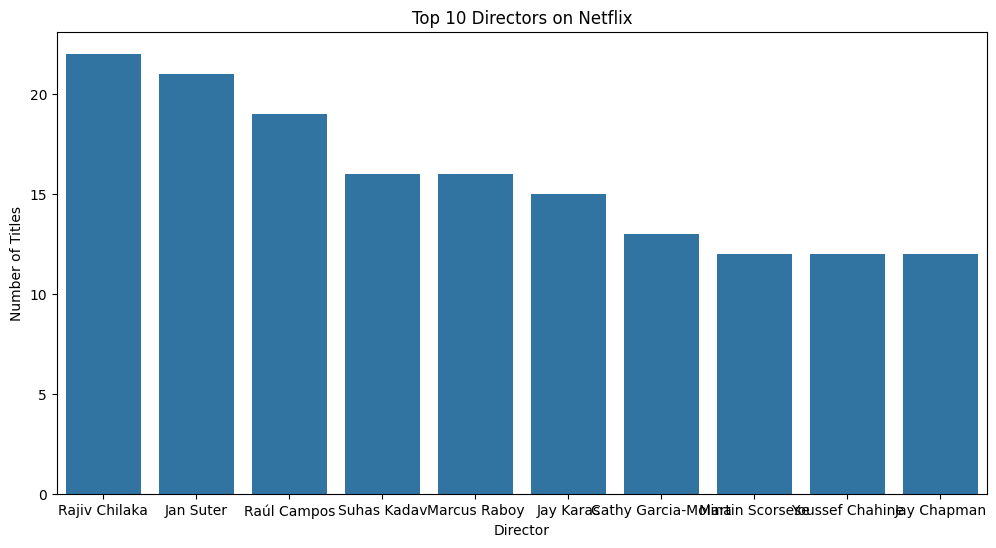

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(x=top_directors.index, y=top_directors.values)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()

In [28]:
print("Director with most titles:", top_directors.index[0])

Director with most titles: Rajiv Chilaka


In [29]:
print("===== Netflix Analysis Summary =====")
print()
print("1. Most Available Content Type:")
print(content_count.idxmax())
print()
print("2. Top Contributing Country:")
print(top_countries.idxmax())
print()
print("3. Director with Most Titles:")
print(top_directors.idxmax())

===== Netflix Analysis Summary =====

1. Most Available Content Type:
Movie

2. Top Contributing Country:
United States

3. Director with Most Titles:
Rajiv Chilaka
